# Small-sized Inversions
Here, we visualize the inversions that were identified for the `small` treatment across the range of depths for the **90% threshold** called variants. An extra consideration here is that with the deconvolution-during-concatenation step, Harpy was unable to call variants on the 10X and 20X data because there were too many molecules (more than the 96^4 possible with haplotagging).

In [15]:
library(ggplot2)

read_data <- function(size_treatment, depth){
    truthfile <- paste0("simulated_data/inversions/", size_treatment, "/inv.", size_treatment,".vcf")
    samplesfile <- paste("simulated_data/called_sv/leviathan90", size_treatment, depth , "by_sample/inversions.bedpe", sep = "/")
    poolfile <- paste("simulated_data/called_sv/leviathan90", size_treatment, depth, "by_pop/inversions.bedpe", sep = "/")

    true_inversions <- read.table(truthfile, header = F)[,c(1,2,8)]
    true_inversions$V8 <- as.numeric(unlist(lapply(true_inversions$V8, function(X){gsub(".+END=", "", X)})))
    names(true_inversions) <- c("contig", "position_start", "position_end")
    true_inversions$sample <- factor(c("simulated_inversions"))

    sample_inversions <- read.table(
        paste("simulated_data/called_sv/leviathan90", size_treatment, depth, "by_sample/inversions.bedpe", sep = "/"),
        header = T
    )[,1:4]
    sample_inversions$sample <- as.factor(sample_inversions$sample)
    if(file.exists(poolfile)){
        pooled_inversions <- read.table(poolfile, header = T)
        pooled_inversions <- pooled_inversions[,c("population","contig", "position_start", "position_end")]
        names(pooled_inversions)[1] <- "sample"
        if(nrow(pooled_inversions > 0)){
            pooled_inversions$sample <- factor(paste("pooled", depth, size_treatment, sep = "_"))
        }
    } else {
        # get an empty copy
        pooled_inversions <- sample_inversions[0, ]
    }
    return(
        rbind(true_inversions, sample_inversions, pooled_inversions)
    )
}
plot_data <- function(data, size_treatment, depth){
    axis_ticks <- c(paste0("sample_", sprintf("%02d", 1:10), ".", depth), "simulated_inversions")
    ggplot(
        data,
        aes(
            x = position_start,
            xend = position_end,
            y = sample,
            yend = sample,
            color = sample
        )
    ) +
        scale_x_continuous(labels = scales::comma) +
        scale_y_discrete(limits = axis_ticks) +
        labs(title = "Called Inversions", subtitle = paste(size_treatment, depth), x = "genomic position (bp)", caption = "Simulated inversions (groundtruth) shown in top row") + 
        geom_segment(linewidth = 2) +
        facet_wrap(~contig, ncol = 1, scales = "free_x") +
        theme_light() +
        theme(panel.grid.major.y = element_blank(), legend.position = "None")
}

Set a global variable `.size` to `"small"` to avoid writing it each time

In [16]:
.size <- "small"

## 0.5X depth

In [17]:
depth_05X <- read_data(.size, "05X")
tail(depth_05X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<fct>
15,3R,25379867,25402914,simulated_inversions
16,3L,4085868,4090818,simulated_inversions
17,3L,14492093,14496538,simulated_inversions
18,3L,17994845,18016735,simulated_inversions
19,3L,24140993,24156318,simulated_inversions
20,3L,26678791,26687230,simulated_inversions


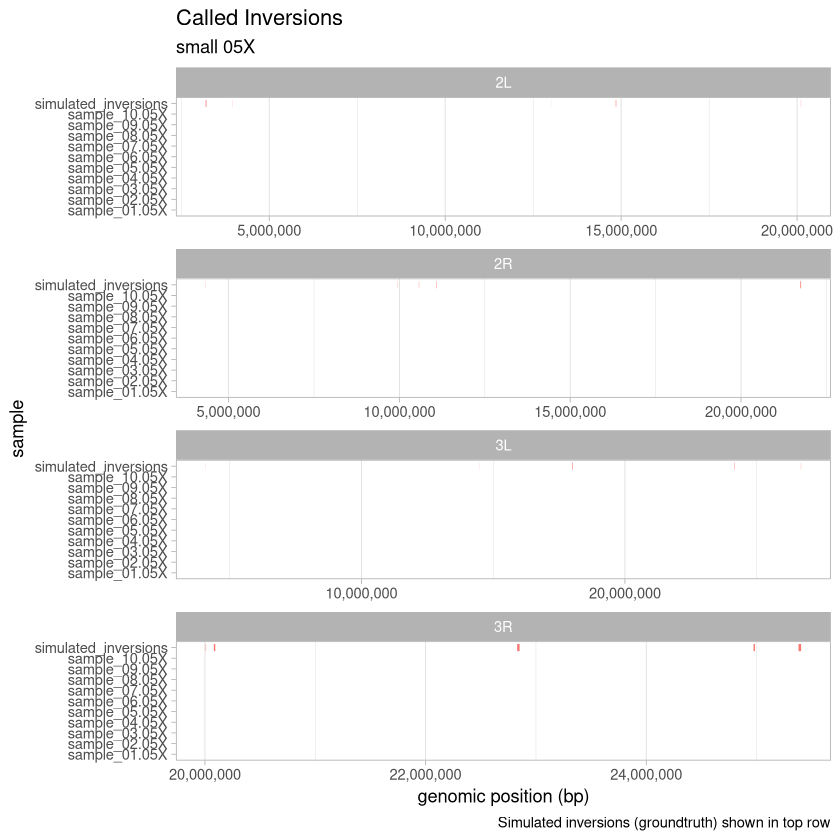

In [18]:
plot_data(depth_05X, .size, "05X")

## 2X Depth

In [19]:
depth_2X <- read_data(.size, "2X")
tail(depth_2X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<fct>
50,2L,14845709,14861199,sample_08.2X
51,2R,11083685,11094907,sample_08.2X
52,3R,20081036,20093594,sample_08.2X
53,3R,25379866,25402914,sample_08.2X
54,2L,3193195,3214221,sample_06.2X
55,2L,3940210,3944863,sample_06.2X


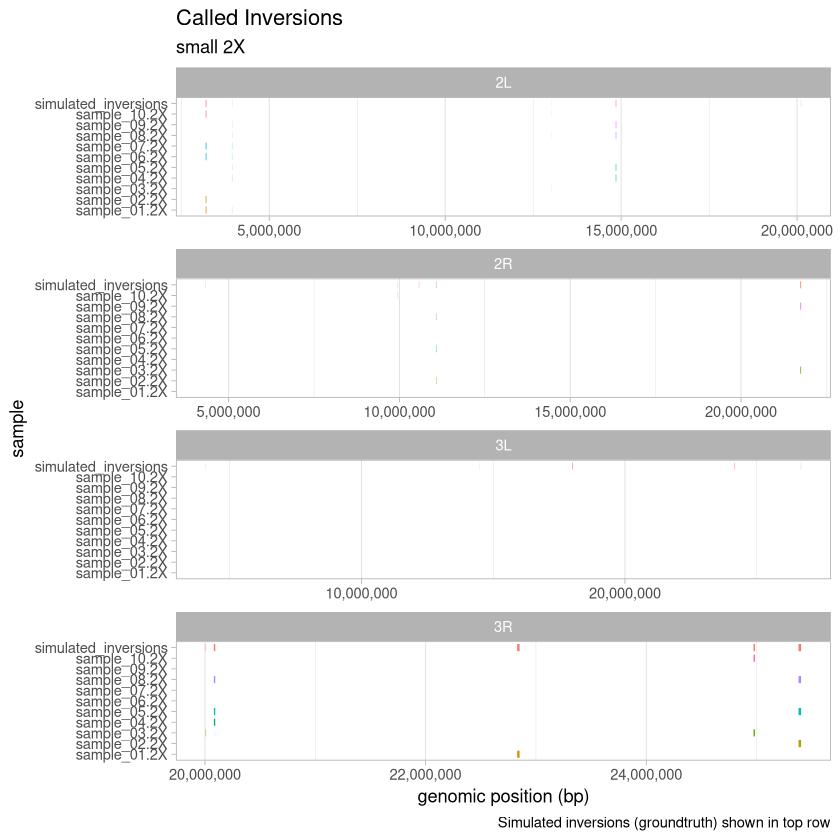

In [20]:
plot_data(depth_2X, .size, "2X")

## 5X Depth

In [21]:
depth_5X <- read_data(.size, "5X")
tail(depth_5X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<fct>
113,2L,13024404,13026576,sample_04.5X
114,2L,14845709,14861200,sample_04.5X
115,2L,20107900,20113695,sample_04.5X
116,2R,10569436,10578078,sample_04.5X
117,3R,20081036,20093594,sample_04.5X
118,3R,22829881,22851517,sample_04.5X


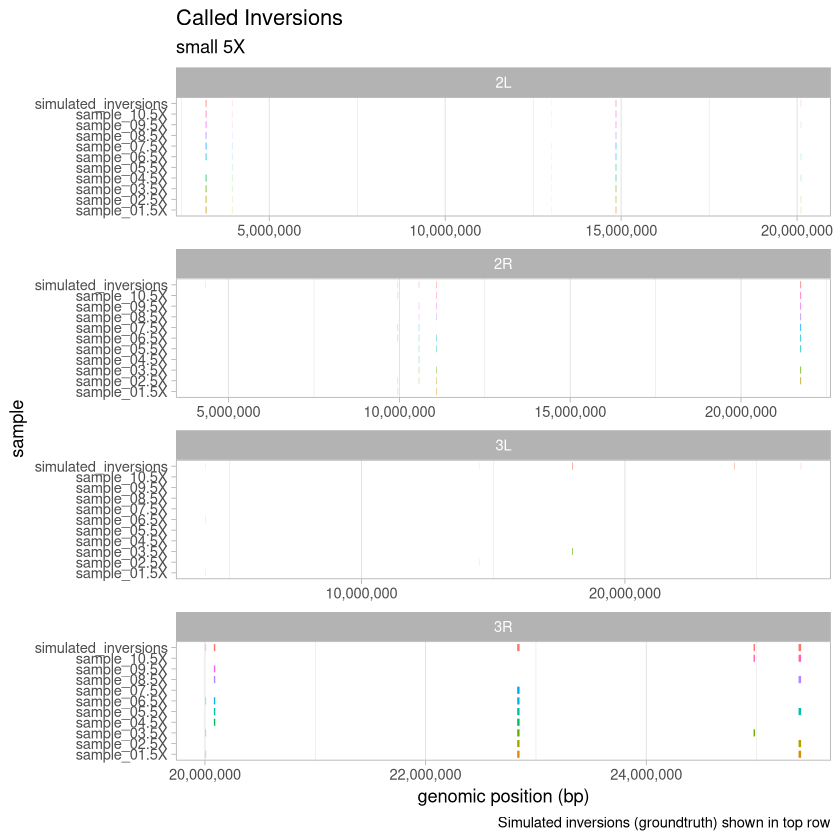

In [22]:
plot_data(depth_5X, .size, "5X")

## 10X Depth

In [23]:
depth_10X <- read_data(.size, "10X")
tail(depth_10X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<fct>
136,2L,20107900,20113695,sample_10.10X
137,2R,9952839,9959287,sample_10.10X
138,2R,10569436,10578080,sample_10.10X
139,2R,11083685,11094907,sample_10.10X
140,3R,24971984,24984761,sample_10.10X
141,3R,25379866,25402914,sample_10.10X


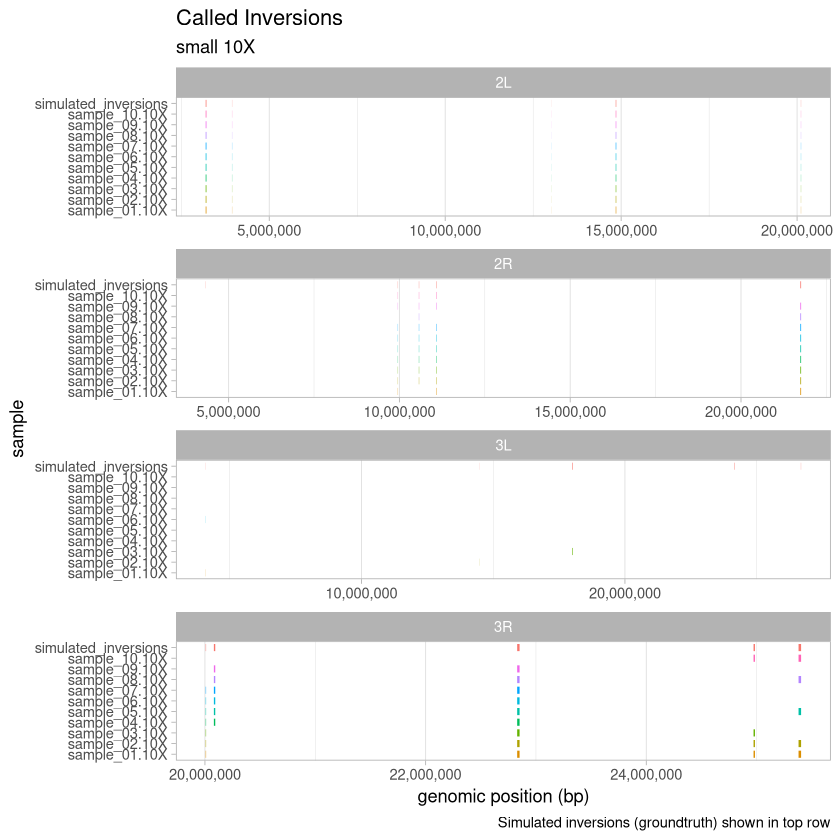

In [24]:
plot_data(depth_10X, .size, "10X")

## 20X Depth

In [25]:
depth_20X <- read_data(.size, "20X")
tail(depth_20X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<fct>
140,2R,11083685,11094907,sample_05.20X
141,2R,21736721,21759356,sample_05.20X
142,3R,20006863,20010483,sample_05.20X
143,3R,20081036,20093594,sample_05.20X
144,3R,22829882,22851519,sample_05.20X
145,3R,25379866,25402914,sample_05.20X


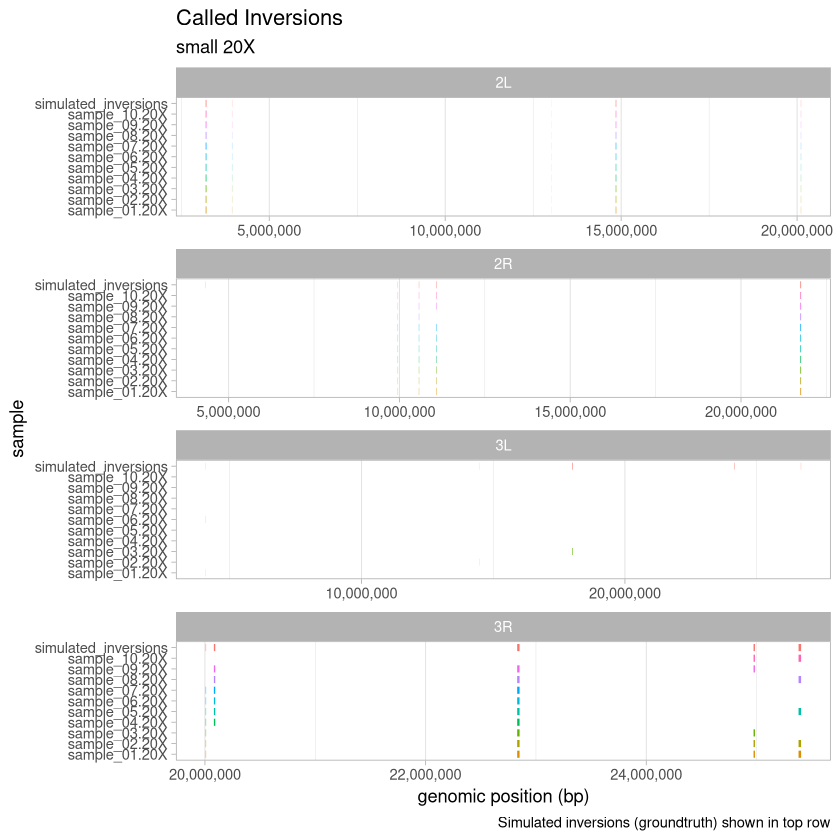

In [26]:
plot_data(depth_20X, .size, "20X")